In [2]:
import sys
sys.path.insert(1, '..')

import os

import vector, hist
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm

from physics.simulation import mcfm, msq
from physics.analysis import zpair

In [3]:
SAMPLE_SIZE = 2000000

SAMPLE_DIR = '../..'

COMPONENT = msq.Component.SIG

In [4]:
xs = {
    msq.Component.SBI : 1.5569109,
    msq.Component.SIG : 0.15105108,
    msq.Component.INT : -0.22043824,
    msq.Component.BKG : 1.6270497
}

filenames = {
    msq.Component.SBI : 'ggZZ2e2m_sbi.csv',
    msq.Component.SIG : 'ggZZ2e2m_sig.csv',
    msq.Component.INT : 'ggZZ2e2m_int.csv',
    msq.Component.BKG : 'ggZZ2e2m_bkg.csv'
}

In [ ]:
events = mcfm.from_csv(cross_section=xs[COMPONENT], file_path=os.path.join(SAMPLE_DIR, filenames[COMPONENT]))

z_cand_truth = zpair.ZPairCandidate(algorithm='truth')
z_cand_lsq = zpair.ZPairCandidate(algorithm='leastsquare')
z_cand_cls = zpair.ZPairCandidate(algorithm='closest')

events_truth = events.calculate(z_cand_truth)
events_lsq = events.calculate(z_cand_lsq)
events_cls = events.calculate(z_cand_cls)

15.573816383864997


In [6]:
mZ1_truth, mZ2_truth = events_truth.kinematics[['Z1_mass','Z2_mass']].to_numpy().T
mZ1_lsq, mZ2_lsq = events_lsq.kinematics[['Z1_mass', 'Z2_mass']].to_numpy().T
mZ1_cls, mZ2_cls = events_cls.kinematics[['Z1_mass', 'Z2_mass']].to_numpy().T

In [7]:
print(mZ1_truth+mZ2_truth)
print(mZ1_lsq+mZ2_lsq)

a = (mZ1_truth+mZ2_truth)[np.where(~np.equal(mZ1_truth+mZ2_truth, mZ1_lsq+mZ2_lsq))[0]]
b = (mZ1_lsq+mZ2_lsq)[np.where(~np.equal(mZ1_truth+mZ2_truth, mZ1_lsq+mZ2_lsq))[0]]

[190.81775244 174.30531003 183.08871471 ... 196.63210952 174.6256262
 186.26209672]
[190.81775244 174.30531003 183.08871471 ... 196.63210952 174.6256262
 186.26209672]


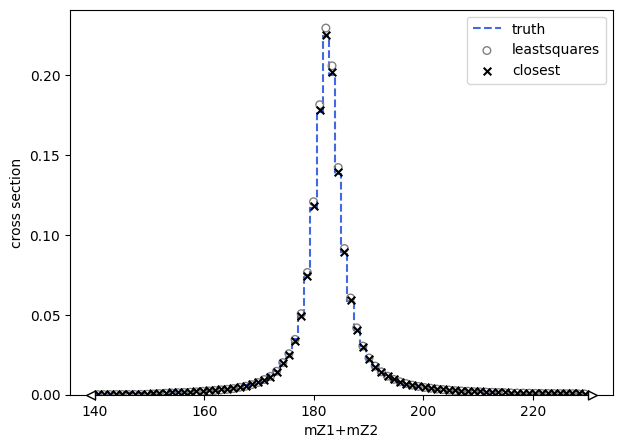

In [30]:
bins = 80
bounds = [140,230]
#bounds = [70,115]

h_cls = hist.Hist(hist.axis.Regular(bins, *bounds))
h_cls.fill(mZ1_cls+mZ2_cls, weight=events_cls.weights)

h_lsq = hist.Hist(hist.axis.Regular(bins, *bounds))
h_lsq.fill(mZ1_lsq+mZ2_lsq, weight=events_lsq.weights)

h_truth = hist.Hist(hist.axis.Regular(bins, *bounds))
h_truth.fill(mZ1_truth+mZ1_truth, weight=events_truth.weights)

fig = plt.figure(figsize=(7,5))

#plt.yscale('log')

h_truth.plot(color='royalblue', linestyle='dashed', label='truth')
plt.scatter(h_lsq.axes[0].centers, h_lsq.values(), s=30, color='grey', marker='o', facecolors='none', label='leastsquares')
plt.scatter(h_cls.axes[0].centers, h_cls.values(), s=30, color='black', marker='x', label='closest')

plt.xlabel('mZ1+mZ2')
plt.ylabel('cross section')

plt.legend()

Text(20.72222222222222, 0.5, 'Sum of Z masses (lsq)')

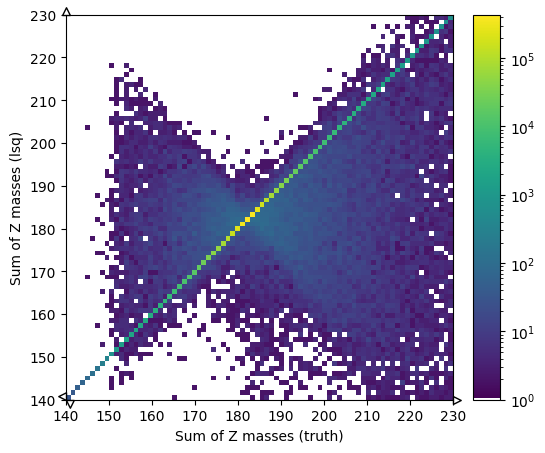

In [9]:
bins = 80
bounds = [140,230]

h_lsq = hist.Hist(hist.axis.Regular(bins, *bounds),
                  hist.axis.Regular(bins, *bounds))
h_lsq.fill(mZ1_truth+mZ2_truth, mZ1_lsq+mZ2_lsq)

cmap = colors.ListedColormap(['white'] + plt.cm.viridis.colors[1:])

fig = plt.figure(figsize=(5,5))

h_lsq.plot2d(cmap=cmap, cbar=True, norm=LogNorm())
plt.xlabel('Sum of Z masses (truth)')
plt.ylabel('Sum of Z masses (lsq)')

Text(20.72222222222222, 0.5, 'Sum of Z masses (cls)')

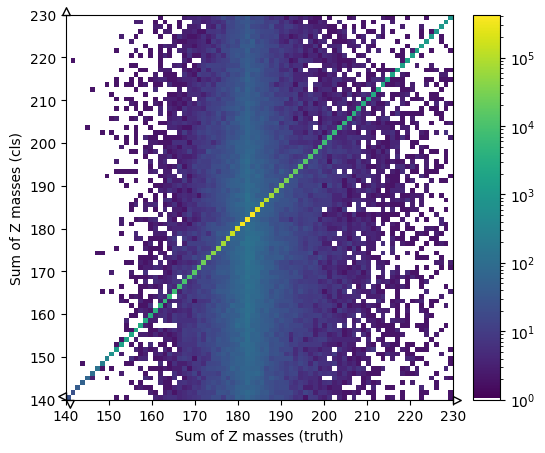

In [10]:
bins = 80
bounds = [140,230]

h_lsq = hist.Hist(hist.axis.Regular(bins, *bounds),
                  hist.axis.Regular(bins, *bounds))
h_lsq.fill(mZ1_truth+mZ2_truth, mZ1_cls+mZ2_cls)

cmap = colors.ListedColormap(['white'] + plt.cm.viridis.colors[1:])

fig = plt.figure(figsize=(5,5))

h_lsq.plot2d(cmap=cmap, cbar=True, norm=LogNorm())
plt.xlabel('Sum of Z masses (truth)')
plt.ylabel('Sum of Z masses (cls)')

In [11]:
print(np.sum(mZ1_lsq-mZ2_lsq>0.0))

2931780


In [12]:
print(f'Total number of events {len(mZ1_lsq)}')
print(f'Accuracy lsq: {np.sum(np.equal(mZ1_truth+mZ2_truth, mZ1_lsq+mZ2_lsq))/len(mZ1_lsq)*100}')
print(f'Accuracy cls: {np.sum(np.equal(mZ1_truth+mZ2_truth, mZ1_cls+mZ2_cls))/len(mZ1_lsq)*100}')

Total number of events 2931780
Accuracy lsq: 98.46417534739987
Accuracy cls: 96.85743814338046


In [13]:
tr_lsq_equal = np.equal(mZ1_truth+mZ2_truth, mZ1_lsq+mZ2_lsq)
tr_cls_equal = np.equal(mZ1_truth+mZ2_truth, mZ1_cls+mZ2_cls)
lsq_cls_equal = np.equal(mZ1_lsq+mZ2_lsq, mZ1_cls+mZ2_cls)

In [14]:
print(f'Cases where lsq and cls are correct: {np.sum(np.logical_and(tr_lsq_equal, tr_cls_equal))/len(mZ1_lsq)*100}')
print(f'Cases where only lsq is correct: {np.sum(np.logical_and(tr_lsq_equal, ~tr_cls_equal))/len(mZ1_lsq)*100}')
print(f'Cases where only cls is correct: {np.sum(np.logical_and(~tr_lsq_equal, tr_cls_equal))/len(mZ1_lsq)*100}')
print(f'Cases where both are wrong: {np.sum(np.logical_and(~tr_lsq_equal, ~tr_cls_equal))/len(mZ1_lsq)*100}')

Cases where lsq and cls are correct: 95.87509976874118
Cases where only lsq is correct: 2.589075578658699
Cases where only cls is correct: 0.9823383746392976
Cases where both are wrong: 0.5534862779608293
